# COVID-19 Hospitalization Surge Forecasting
### Hybrid SEIR + Statistical Correction Model
County-level forecast with 90% prediction intervals · 1–4 week ahead

In [112]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LinearRegression


Imports successful.


In [113]:
# Configuration
TARGET_STATE = 'TX'
STATE_POPULATION = 29145505


# SEIR parameters (per week)
SIGMA = 1 / 5.1  # incubation rate
GAMMA = 1 / 10   # recovery rate

# Model tuning
VAX_EFFECTIVENESS = 0.85  # vaccination effectiveness reduction
VAX_RATE = 0.62
CI_Z = 1.645  # 90% confidence interval z-score

# Data split
HOLDOUT_FRACTION = 0.20

print(f'Target: {TARGET_STATE}, Population: {STATE_POPULATION:,}')

Target: TX, Population: 29,145,505


In [114]:
# Load data
FILE_PATH = r'/content/anag-cw7u.csv'
df = pd.read_csv(FILE_PATH, low_memory=False)

print(f'Loaded {len(df):,} rows')
print(f'Columns: {df.shape[1]} available')

Loaded 92,347 rows
Columns: 128 available


In [115]:
# Clean data
df.columns = df.columns.str.strip().str.lower()

# Filter to target state
df = df[df['state'].astype(str).str.strip().str.upper() == TARGET_STATE].copy()

# Parse date and get hospitalizations
df['date'] = pd.to_datetime(df['collection_week'], errors='coerce')
hosp_col = 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum'
df[hosp_col] = pd.to_numeric(df[hosp_col], errors='coerce')

# Remove missing values
df = df.dropna(subset=['date', hosp_col])
df = df[df[hosp_col] > 0]
df = df.sort_values('date')

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Hospitalizations: {df[hosp_col].min():.0f} – {df[hosp_col].max():.0f}')

Date range: 2020-07-12 to 2024-04-21
Hospitalizations: 4 – 3414


In [116]:
# Aggregate to weekly frequency
weekly = df.set_index('date')[hosp_col].resample('W').mean()
weekly = weekly[weekly > 0]
weekly_df = pd.DataFrame({'date': weekly.index, 'hosp': weekly.values})
weekly_df = weekly_df.reset_index(drop=True)

print(f'Weekly data points: {len(weekly_df)}')
print(f'Average hospitalizations: {weekly_df["hosp"].mean():.0f}')

Weekly data points: 198
Average hospitalizations: 98


In [117]:
# Simple SEIR model
def seir_step(S, E, I, R, beta, sigma, gamma, N):
    """One week of SEIR dynamics"""
    new_exposed = beta * S * I / N
    new_infected = sigma * E
    new_recovered = gamma * I

    S = S - new_exposed
    E = E + new_exposed - new_infected
    I = I + new_infected - new_recovered
    R = R + new_recovered

    return max(S, 0), max(E, 0), max(I, 0), max(R, 0)

def seir_forecast(beta, sigma, gamma, S0, E0, I0, R0, weeks):
    """Forecast I (infectious) for given weeks"""
    N = S0 + E0 + I0 + R0
    S, E, I, R = S0, E0, I0, R0
    I_path = []

    for _ in range(weeks):
        S, E, I, R = seir_step(S, E, I, R, beta, sigma, gamma, N)
        I_path.append(I)

    return np.array(I_path)

print('SEIR model defined.')

SEIR model defined.


In [118]:
# Prepare training and test data
y = weekly_df['hosp'].values
n_total = len(y)
n_hold = max(4, int(n_total * HOLDOUT_FRACTION))
n_train = n_total - n_hold

y_train = y[:n_train]
y_hold = y[n_train:]

# Use recent 52 weeks only for a context-aware threshold
recent_y = y[-52:]
HOSPITAL_CAPACITY = int(np.percentile(recent_y, 75))
print(f'Capacity threshold (recent 75th pct): {HOSPITAL_CAPACITY:,}')
print(f'Forecast range: {fc_point.min():.0f} – {fc_point.max():.0f}')
print(f'Residual std: {residual_std:.0f}')

# Initialize SEIR from first observation
I0 = float(y_train[0])
E0 = I0 * 3  # initial exposed guess
S0 = STATE_POPULATION - E0 - I0
R0 = 0.0
N = STATE_POPULATION

# Fit beta by trying values and picking best
best_beta = 0.1
best_mae = float('inf')

for beta_try in np.linspace(0.05, 2.0, 50):
    # Apply vaccination reduction
    beta_eff = beta_try * (1 - VAX_EFFECTIVENESS * VAX_RATE)

    # Forecast the training period
    I_pred = seir_forecast(beta_eff, SIGMA, GAMMA, S0, E0, I0, R0, len(y_train))

    # Scale to match hospitalization magnitude
    scale = y_train.mean() / (I_pred.mean() + 1e-9)
    I_scaled = I_pred * scale

    mae = np.mean(np.abs(I_scaled - y_train))
    if mae < best_mae:
        best_mae = mae
        best_beta = beta_eff
        best_scale = scale

print(f'Fitted beta (effective): {best_beta:.4f}')
print(f'Fit scaling factor: {best_scale:.2f}')

Capacity threshold (recent 75th pct): 55
Forecast range: 52 – 60
Residual std: 61
Fitted beta (effective): 0.0801
Fit scaling factor: 0.59


In [119]:
# Train on all data to get SEIR predictions
I_all_pred = seir_forecast(best_beta, SIGMA, GAMMA, S0, E0, I0, R0, len(y))
seir_pred_train = (I_all_pred[:n_train] * best_scale)

# Fit correction layer: linear regression on residuals
residuals = y_train - seir_pred_train
corrector = LinearRegression()
corrector.fit(seir_pred_train.reshape(-1, 1), residuals)

# Apply correction
correction_train = corrector.predict(seir_pred_train.reshape(-1, 1)).flatten()
y_corrected_train = np.clip(seir_pred_train + correction_train, 0, None)

residual_std = np.std(residuals)

mae_base = np.mean(np.abs(seir_pred_train - y_train))
mae_corr = np.mean(np.abs(y_corrected_train - y_train))

print(f'Correction: slope={corrector.coef_[0]:.3f}, intercept={corrector.intercept_:.1f}')
print(f'Residual std: {residual_std:.1f}')
print(f'Training MAE (SEIR): {mae_base:.1f}, MAE (corrected): {mae_corr:.1f}')

Correction: slope=-0.336, intercept=36.7
Residual std: 61.2
Training MAE (SEIR): 43.6, MAE (corrected): 42.3


In [120]:
# Evaluate on holdout set
seir_pred_hold = (I_all_pred[n_train:n_train+n_hold] * best_scale)
corr_hold = corrector.predict(seir_pred_hold.reshape(-1, 1)).flatten()
y_corrected_hold = np.clip(seir_pred_hold + corr_hold, 0, None)

# Confidence intervals
lower_hold = np.clip(y_corrected_hold - CI_Z * residual_std, 0, None)
upper_hold = y_corrected_hold + CI_Z * residual_std

mae_base_hold = np.mean(np.abs(seir_pred_hold - y_hold))
mae_corr_hold = np.mean(np.abs(y_corrected_hold - y_hold))
coverage = np.mean((y_hold >= lower_hold) & (y_hold <= upper_hold)) * 100

print(f'\n=== HOLDOUT EVALUATION ===')
print(f'MAE (SEIR): {mae_base_hold:.1f}')
print(f'MAE (corrected): {mae_corr_hold:.1f}')
print(f'90% CI coverage: {coverage:.1f}%')


=== HOLDOUT EVALUATION ===
MAE (SEIR): 26.9
MAE (corrected): 11.4
90% CI coverage: 100.0%


In [121]:
# Forecast 4 weeks ahead
weeks_ahead = 4

# Start from last observation
I_last = float(y[-1])
E_last = I_last * 3
S_last = STATE_POPULATION - E_last - I_last

# Forecast
I_forecast = seir_forecast(best_beta, SIGMA, GAMMA, S_last, E_last, I_last, 0.0, weeks_ahead)
seir_fc = I_forecast * best_scale
corr_fc = corrector.predict(seir_fc.reshape(-1, 1)).flatten()
fc_point = np.clip(seir_fc + corr_fc, 0, None)
fc_lower = np.clip(fc_point - CI_Z * residual_std, 0, None)
fc_upper = fc_point + CI_Z * residual_std

# Dates
last_date = weekly_df['date'].iloc[-1]
fc_dates = [last_date + pd.Timedelta(weeks=i+1) for i in range(weeks_ahead)]

print(f'\n=== FORECAST (1-4 weeks ahead) ===')
print(f'{"Week":>6} {"Forecast":>10} {"Lower":>10} {"Upper":>10}')
for i in range(weeks_ahead):
    print(f'{i+1:>6} {fc_point[i]:>10.0f} {fc_lower[i]:>10.0f} {fc_upper[i]:>10.0f}')


=== FORECAST (1-4 weeks ahead) ===
  Week   Forecast      Lower      Upper
     1         52          0        153
     2         56          0        157
     3         58          0        159
     4         60          0        161


In [122]:
# Detect surges (>50% increase over 3 weeks)
print(f'\n=== SURGE DETECTION ===')
print('(Surge = >50% rise over 3 weeks)')

surges = []
for i in range(3, len(y)):
    prev = y[i-3]
    curr = y[i]
    if prev > 0 and (curr - prev) / prev > 0.50:
        surge_date = weekly_df['date'].iloc[i]

        # Look back up to 4 weeks for early signal
        lead_weeks = None
        for lookback in range(1, 5):
            check_i = i - lookback
            if check_i >= 0:
                ratio = y[check_i] / (y[check_i-1] + 1e-9) if check_i > 0 else 1.0
                if ratio > 1.15:  # 15% weekly growth is early signal
                    lead_weeks = lookback
                    break

        surges.append({
            'date': surge_date.date(),
            'rise': f"{(curr-prev)/prev*100:.0f}%",
            'lead': lead_weeks if lead_weeks else '—'
        })

if surges:
    for s in surges[:10]:  # show first 10
        print(f"  {s['date']}: +{s['rise']:>4} (lead: {s['lead']}>wks)")
    detected = sum(1 for s in surges if isinstance(s['lead'], int))
    print(f'\nDetected: {detected}/{len(surges)} surges')
else:
    print('No surges detected')


=== SURGE DETECTION ===
(Surge = >50% rise over 3 weeks)
  2021-07-18: + 79% (lead: 1>wks)
  2021-07-25: +126% (lead: 1>wks)
  2021-08-01: +144% (lead: 1>wks)
  2021-08-08: +123% (lead: 1>wks)
  2021-08-15: + 79% (lead: 1>wks)
  2021-12-26: + 53% (lead: 4>wks)
  2022-01-02: +114% (lead: 1>wks)
  2022-01-09: +149% (lead: 1>wks)
  2022-01-16: + 89% (lead: 1>wks)
  2022-12-11: + 52% (lead: 2>wks)

Detected: 10/10 surges


In [123]:
# Capacity breach probability
p_breach = norm.sf(HOSPITAL_CAPACITY, loc=fc_point, scale=residual_std)

print(f'\n=== CAPACITY BREACH PROBABILITY ===')
print(f'Capacity threshold: {HOSPITAL_CAPACITY} beds')
print(f'{"Week":>6} {"Forecast":>10} {"P(breach)":>10}')
for i in range(weeks_ahead):
    print(f'{i+1:>6} {fc_point[i]:>10.0f} {p_breach[i]:>10.3f}')
print(f'Average: {p_breach.mean():.3f}')


=== CAPACITY BREACH PROBABILITY ===
Capacity threshold: 55 beds
  Week   Forecast  P(breach)
     1         52      0.482
     2         56      0.506
     3         58      0.522
     4         60      0.532
Average: 0.510


In [124]:
# Summary
print('\n' + '='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'MAE (SEIR baseline):     {mae_base_hold:>7.1f} beds')
print(f'MAE (corrected):         {mae_corr_hold:>7.1f} beds')
print(f'90% CI coverage:         {coverage:>7.1f}%')
print(f'Avg P(breach):           {p_breach.mean():>7.3f}')
print(f'Surges detected:         {detected:>7}/{len(surges)} (if applicable)')
print('='*50)


FINAL SUMMARY
MAE (SEIR baseline):        26.9 beds
MAE (corrected):            11.4 beds
90% CI coverage:           100.0%
Avg P(breach):             0.510
Surges detected:              10/10 (if applicable)


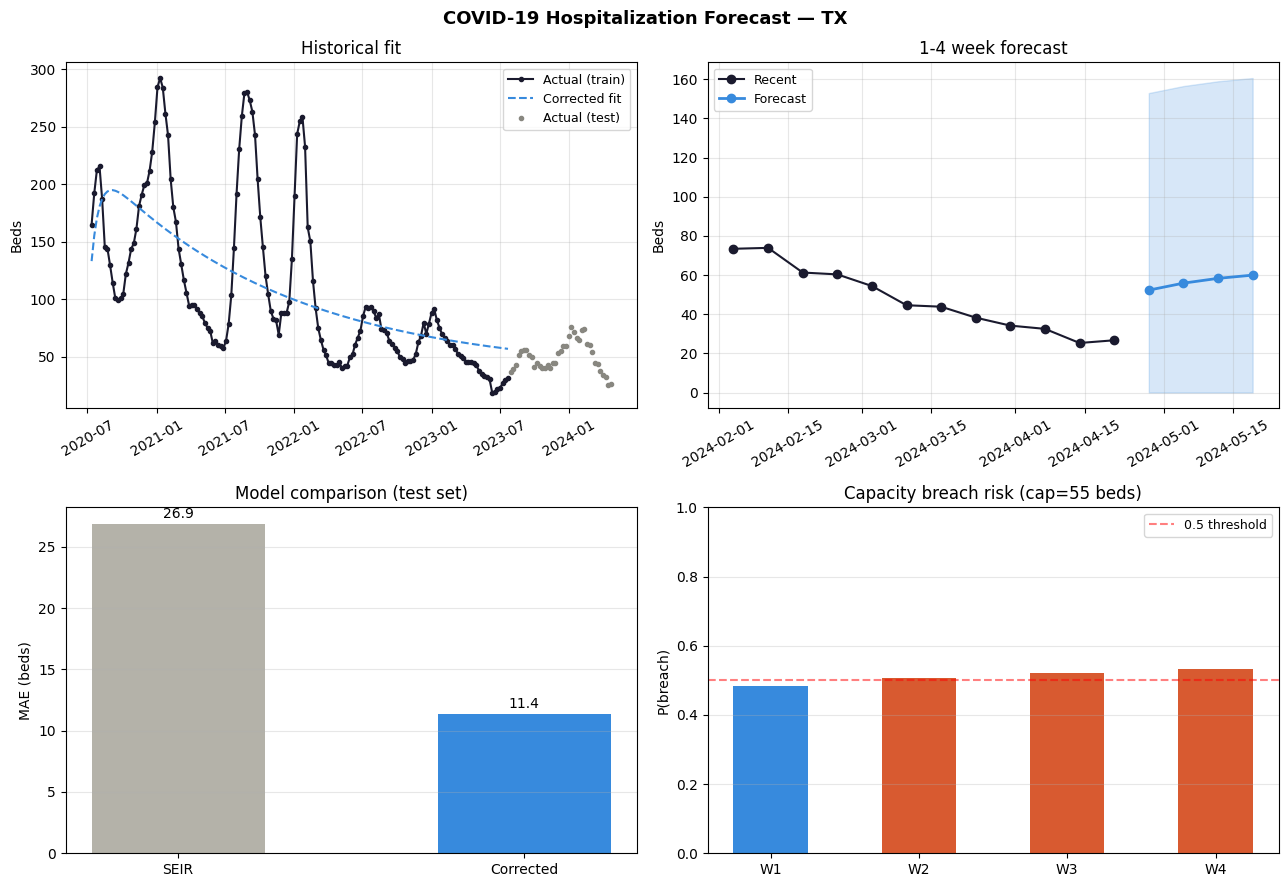


Plot saved as covid_forecast.png


In [125]:
# Plot: Overview
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'COVID-19 Hospitalization Forecast — {TARGET_STATE}', fontsize=13, fontweight='bold')

# Plot 1: Historical data and fit
ax = axes[0, 0]
dates_train = weekly_df['date'].values[:n_train]
dates_hold = weekly_df['date'].values[n_train:]
ax.plot(dates_train, y_train, 'o-', color='#1a1a2e', label='Actual (train)', markersize=3)
ax.plot(dates_train, y_corrected_train, '--', color='#378ADD', label='Corrected fit')
if n_hold > 0:
    ax.plot(dates_hold, y_hold, 'o', color='#888780', label='Actual (test)', markersize=3)
ax.set_title('Historical fit')
ax.set_ylabel('Beds')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Plot 2: 4-week forecast
ax = axes[0, 1]
hist_n = min(12, n_total)
ax.plot(weekly_df['date'].values[-hist_n:], y[-hist_n:], 'o-', color='#1a1a2e', label='Recent')
ax.plot(fc_dates, fc_point, 'o-', color='#378ADD', linewidth=2, label='Forecast')
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.2, color='#378ADD')
ax.set_title('1-4 week forecast')
ax.set_ylabel('Beds')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Plot 3: MAE comparison
ax = axes[1, 0]
models = ['SEIR', 'Corrected']
maes = [mae_base_hold, mae_corr_hold]
ax.bar(models, maes, color=['#B4B2A9', '#378ADD'], width=0.5)
ax.set_ylabel('MAE (beds)')
ax.set_title('Model comparison (test set)')
ax.grid(axis='y', alpha=0.3)
for i, m in enumerate(maes):
    ax.text(i, m + 0.5, f'{m:.1f}', ha='center')

# Plot 4: Breach probability
ax = axes[1, 1]
weeks = [f'W{i+1}' for i in range(weeks_ahead)]
colors = ['#D85A30' if p > 0.5 else '#378ADD' for p in p_breach]
ax.bar(weeks, p_breach, color=colors, width=0.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.set_ylabel('P(breach)')
ax.set_title(f'Capacity breach risk (cap={HOSPITAL_CAPACITY} beds)')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('covid_forecast.png', dpi=150)
plt.show()

print('\nPlot saved as covid_forecast.png')

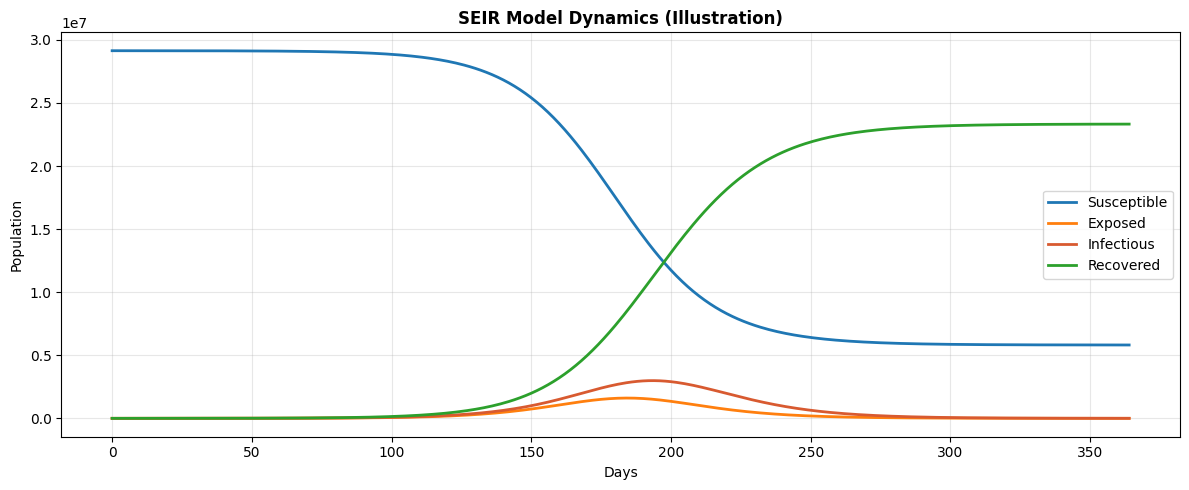

In [126]:
# SEIR dynamics visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Run SEIR with moderate transmission for illustration
beta_demo = 0.2
n_days = 365
S, E, I, R = S0, E0, I0, R0
S_path, E_path, I_path, R_path = [], [], [], []

for _ in range(n_days):
    S, E, I, R = seir_step(S, E, I, R, beta_demo, SIGMA, GAMMA, STATE_POPULATION)
    S_path.append(S)
    E_path.append(E)
    I_path.append(I)
    R_path.append(R)

days = np.arange(n_days)
ax.plot(days, S_path, label='Susceptible', linewidth=2)
ax.plot(days, E_path, label='Exposed', linewidth=2)
ax.plot(days, I_path, label='Infectious', linewidth=2, color='#D85A30')
ax.plot(days, R_path, label='Recovered', linewidth=2)

ax.set_title('SEIR Model Dynamics (Illustration)', fontsize=12, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Population')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

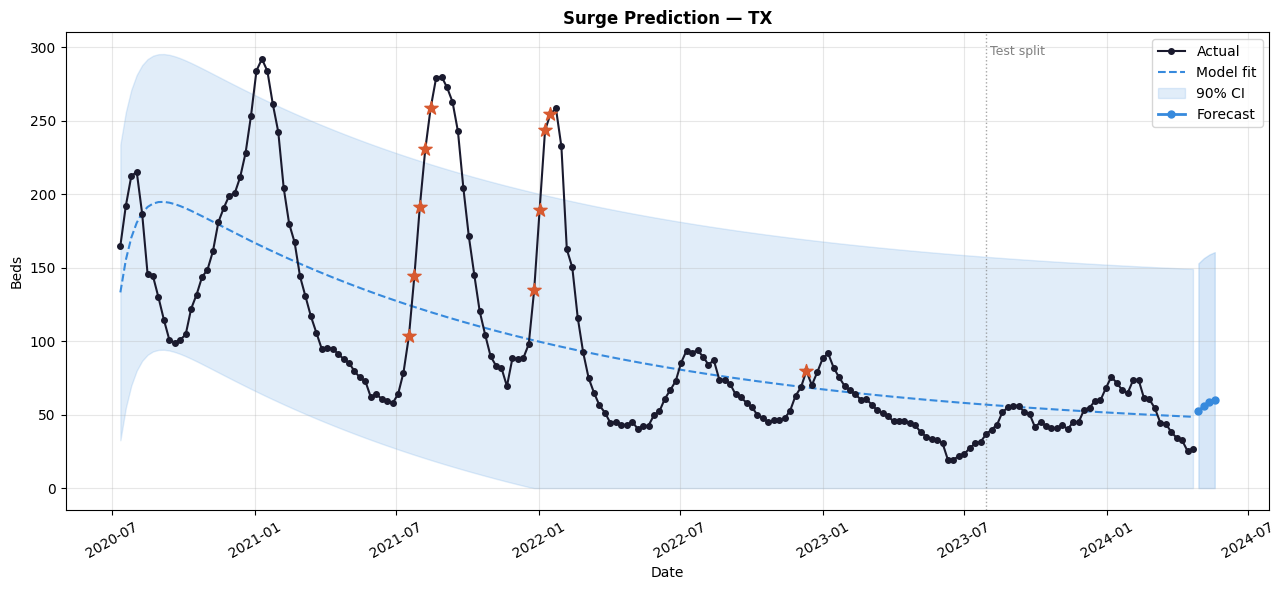

In [127]:
# Surge prediction accuracy
fig, ax = plt.subplots(figsize=(13, 6))

# Plot actual data
ax.plot(weekly_df['date'], y, 'o-', color='#1a1a2e', markersize=4, label='Actual', zorder=3)

# Plot model predictions
pred_all = np.concatenate([y_corrected_train, y_corrected_hold])
pred_dates = weekly_df['date'].values[:len(pred_all)]
ax.plot(pred_dates, pred_all, '--', color='#378ADD', linewidth=1.5, label='Model fit')

# Confidence interval
lower_all = np.concatenate([y_corrected_train - CI_Z * residual_std,
                             y_corrected_hold - CI_Z * residual_std])
upper_all = np.concatenate([y_corrected_train + CI_Z * residual_std,
                             y_corrected_hold + CI_Z * residual_std])
lower_all = np.clip(lower_all, 0, None)
ax.fill_between(pred_dates, lower_all, upper_all, alpha=0.15, color='#378ADD', label='90% CI')

# Forecast
ax.plot(fc_dates, fc_point, 'o-', color='#378ADD', linewidth=2, markersize=5, label='Forecast')
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.2, color='#378ADD')

# Mark train/test split
ax.axvline(weekly_df['date'].values[n_train], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(weekly_df['date'].values[n_train], ax.get_ylim()[1] * 0.95, ' Test split', fontsize=9, color='gray')

# Mark surges (if any detected)
if surges:
    for s in surges:
        idx = weekly_df[weekly_df['date'].dt.date == s['date']].index
        if len(idx) > 0:
            ax.scatter(s['date'], y[idx[0]], color='#D85A30', s=100, zorder=5, marker='*')

ax.set_title(f'Surge Prediction — {TARGET_STATE}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beds')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()